Use the SHAP library to visualize Probatus results
=========================================

This notebook demonstrates how to:

1. Use Probatus to generate SHAP values for a model
2. Create standard SHAP visualizations with Probatus
3. Create advanced visualizations using the SHAP library directly
   - SHAP summary plot (already included in Probatus)
   - SHAP interaction plots
4. Analyze feature importance and interactions

In [3]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

# Import Probatus utilities for SHAP
from probatus.utils.shap import calculate_shap_explanation, shap_explanation_to_shap_df, calculate_shap_importance

# Import SHAP library for additional visualizations
import shap

# Set random state for reproducibility
RANDOM_STATE = 42

## Data Preparation

We'll use the breast cancer dataset from scikit-learn as our example.
This is a binary classification task.

In [4]:
# Load the breast cancer dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

# Display dataset information
print(f"Dataset shape: {X.shape}")
print(f"Number of features: {X.shape[1]}")
print(f"Number of classes: {len(np.unique(y))}")
print(f"Class distribution: {pd.Series(y).value_counts().to_dict()}")

# Display feature names
print("\nFeature names:")
for i, name in enumerate(X.columns):
    print(f"{i+1}. {name}")

Dataset shape: (569, 30)
Number of features: 30
Number of classes: 2
Class distribution: {1: 357, 0: 212}

Feature names:
1. mean radius
2. mean texture
3. mean perimeter
4. mean area
5. mean smoothness
6. mean compactness
7. mean concavity
8. mean concave points
9. mean symmetry
10. mean fractal dimension
11. radius error
12. texture error
13. perimeter error
14. area error
15. smoothness error
16. compactness error
17. concavity error
18. concave points error
19. symmetry error
20. fractal dimension error
21. worst radius
22. worst texture
23. worst perimeter
24. worst area
25. worst smoothness
26. worst compactness
27. worst concavity
28. worst concave points
29. worst symmetry
30. worst fractal dimension


In [5]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (398, 30)
Testing set shape: (171, 30)


## Model Training & Evaluation

We'll train a Random Forest classifier and evaluate its performance.

In [6]:
# Train a RandomForest classifier
clf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=RANDOM_STATE)
clf.fit(X_train, y_train)

# Evaluate the model
y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:, 1]

print("Model Performance:")
print(classification_report(y_test, y_pred))
print(f"ROC AUC Score: {roc_auc_score(y_test, y_prob):.4f}")

Model Performance:
              precision    recall  f1-score   support

           0       0.94      0.91      0.92        64
           1       0.94      0.96      0.95       107

    accuracy                           0.94       171
   macro avg       0.94      0.93      0.94       171
weighted avg       0.94      0.94      0.94       171

ROC AUC Score: 0.9893


## Using Probatus to Calculate SHAP Values

Now we'll use Probatus to calculate SHAP values for our model.
Probatus handles many of the details for us, making it easy to get SHAP explanations.

In [8]:
# Calculate SHAP values using Probatus
print("Calculating SHAP values...")
shap_explanation, explainer = calculate_shap_explanation(
    model=clf, X=X_test, return_explainer=True, random_state=RANDOM_STATE, check_additivity=False
)

# Display expected value (baseline)
print(f"Expected value (baseline prediction): {explainer.expected_value}")

Calculating SHAP values...
Expected value (baseline prediction): [0.38313298 0.61686702]


## Converting SHAP Explanation to DataFrame

Probatus provides utilities to convert SHAP explanations to DataFrames,
which makes it easier to work with the values for further analysis.

In [9]:
# Convert SHAP values to DataFrame
shap_values_df = shap_explanation_to_shap_df(shap_explanation=shap_explanation, model=clf, X=X_test)

# Display the first few rows
print("SHAP values DataFrame (first 5 rows):")
print(shap_values_df.head())

SHAP values DataFrame (first 5 rows):
     mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
14      0.003459     -0.014285       -0.000326  -0.001192        -0.014762   
150     0.022561     -0.001064        0.015770   0.011745        -0.000876   
275     0.024738      0.001286        0.010313   0.008735        -0.002955   
83     -0.049247     -0.010157       -0.033099  -0.032404        -0.008583   
86      0.036655     -0.008317        0.007940   0.020399        -0.002271   

     mean compactness  mean concavity  mean concave points  mean symmetry  \
14          -0.022698       -0.039491            -0.058225      -0.003323   
150          0.005852        0.019369             0.020430      -0.000030   
275          0.009628        0.005208            -0.024145      -0.000688   
83          -0.006084       -0.023064            -0.031274       0.001076   
86           0.009676       -0.029106            -0.002388       0.001987   

     mean fractal dimension  .

## Calculating Feature Importance with Probatus

Probatus makes it easy to calculate feature importance based on SHAP values.

Feature importance based on SHAP values:
                         mean_abs_shap_value  mean_shap_value  \
worst area                          0.081656        -0.000672   
worst concave points                0.066836         0.000968   
worst perimeter                     0.046843         0.000329   
worst radius                        0.042894        -0.000546   
mean radius                         0.028908        -0.000976   
mean concave points                 0.022551         0.000263   
worst concavity                     0.022119        -0.000001   
mean perimeter                      0.018987        -0.000255   
mean area                           0.018972        -0.000143   
mean concavity                      0.018871        -0.000356   
area error                          0.017905         0.001217   
worst texture                       0.012370        -0.000461   
worst smoothness                    0.009930        -0.000131   
perimeter error                     0.008951     

<Figure size 1000x800 with 0 Axes>

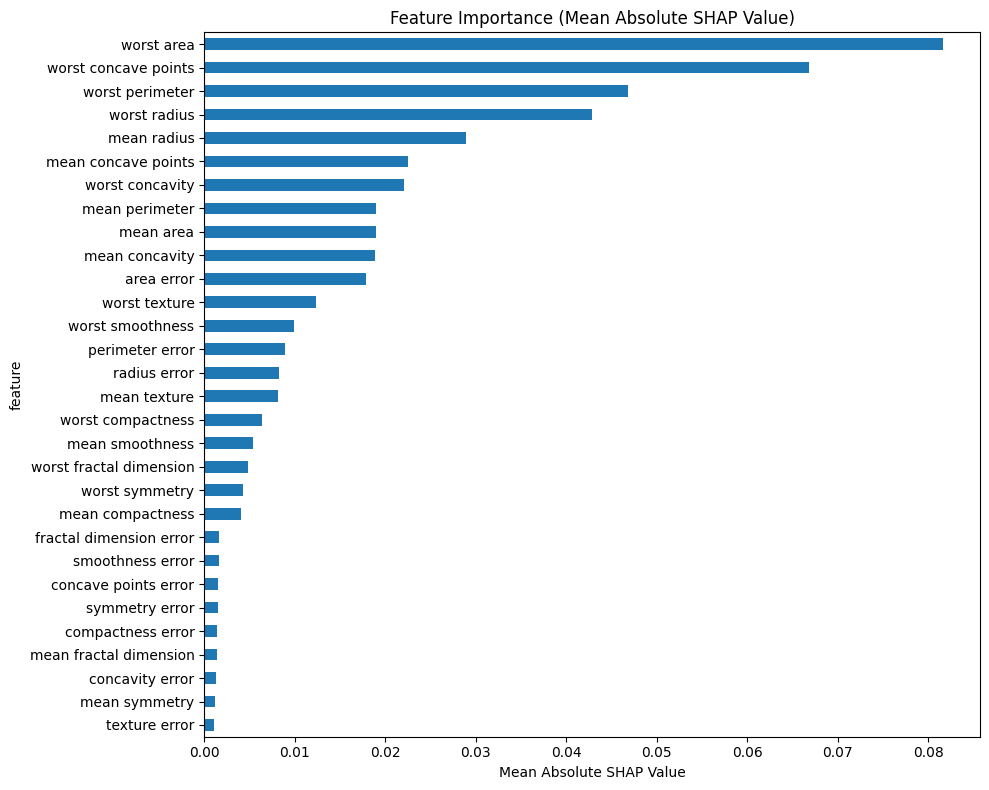

In [16]:
# Calculate feature importance
importance_df = calculate_shap_importance(shap_values=shap_values_df)

# Display importance dataframe
print("Feature importance based on SHAP values:")
print(importance_df)

# Plot feature importance
plt.figure(figsize=(10, 8))
importance_df.index.name = "feature"
importance_df.reset_index(inplace=False).sort_values("mean_abs_shap_value").plot(
    kind="barh", x="feature", y="mean_abs_shap_value", legend=False, figsize=(10, 8)
)
plt.title("Feature Importance (Mean Absolute SHAP Value)")
plt.xlabel("Mean Absolute SHAP Value")
plt.tight_layout()
plt.show()

## Standard SHAP Visualizations

Now let's create some standard SHAP visualizations using the SHAP library directly.

<Figure size 1200x1000 with 0 Axes>

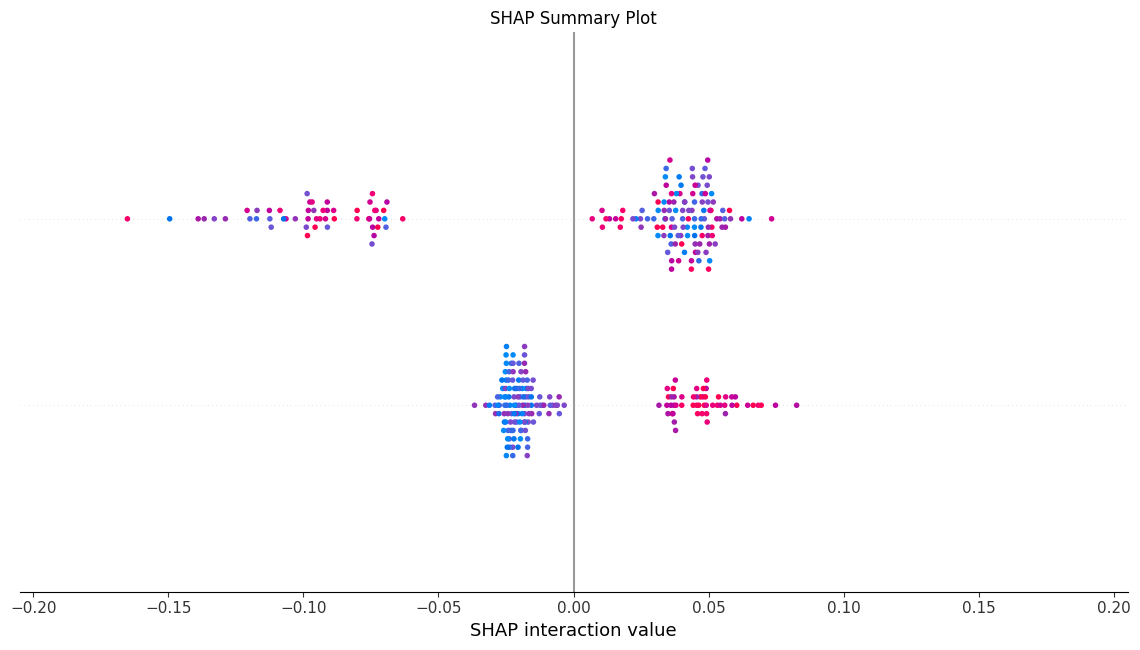

In [17]:
# SHAP Summary Plot
plt.figure(figsize=(12, 10))
shap.summary_plot(shap_explanation.values, X_test, feature_names=X_test.columns, show=False)
plt.title("SHAP Summary Plot")
plt.tight_layout()
plt.show()

## Advanced Visualization 1: SHAP Decision Plot

Decision plots show how the SHAP values of each feature contribute to the model prediction.
They're useful for understanding the cumulative impact of features.

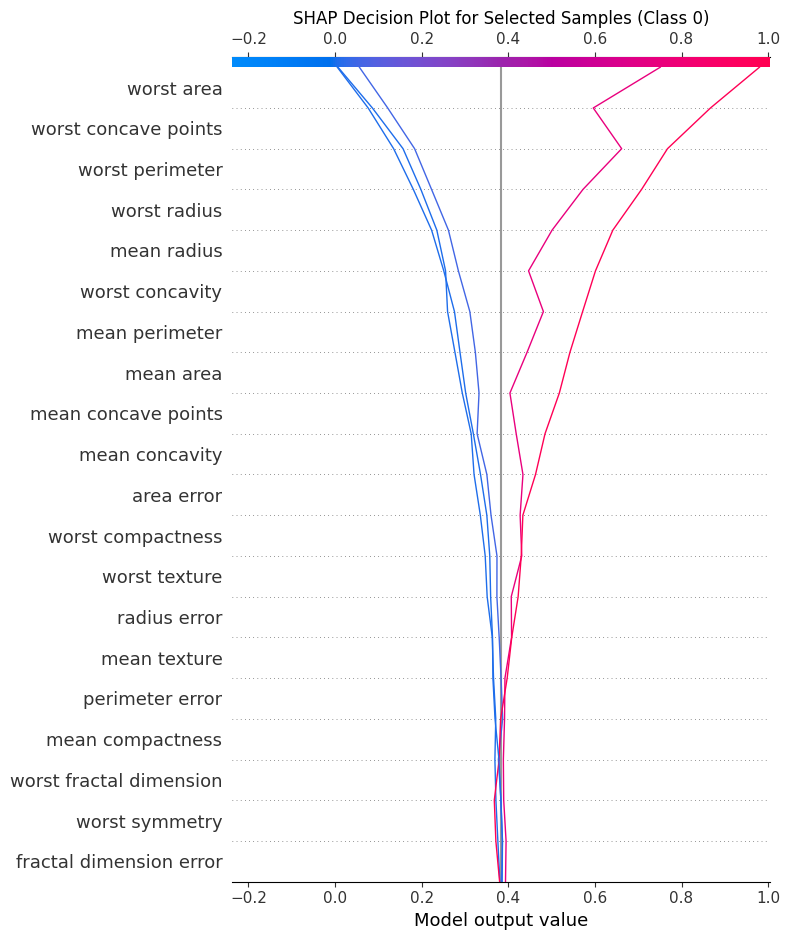

In [ ]:
# Select a few samples for the decision plot
n_samples_decision = 5
sample_indices_decision = np.random.choice(len(X_test), n_samples_decision, replace=False)

# Create a SHAP decision plot
plt.figure(figsize=(12, 8))

# Check if the SHAP values are multiclass (3D array)
if len(shap_explanation.values.shape) == 3:
    # Option 1: Select a specific class (e.g., class 0)
    class_idx = 0  # You can change this to select a different class

    # Use SHAP values for the selected class
    shap.decision_plot(
        explainer.expected_value[class_idx],
        shap_explanation.values[sample_indices_decision, :, class_idx],
        X_test.iloc[sample_indices_decision],
        feature_names=X_test.columns.tolist(),
        show=False,
    )
    plt.title(f"SHAP Decision Plot for Selected Samples (Class {class_idx})")
else:
    # For binary classification or already processed values
    shap.decision_plot(
        explainer.expected_value,
        shap_explanation.values[sample_indices_decision],
        X_test.iloc[sample_indices_decision],
        feature_names=X_test.columns.tolist(),
        show=False,
    )
    plt.title("SHAP Decision Plot for Selected Samples")

plt.tight_layout()
plt.show()

## Conclusion

In this notebook, we've demonstrated:

1. How to use Probatus to calculate SHAP values for a model
2. How to convert SHAP explanations to DataFrames using Probatus
3. How to calculate feature importance using SHAP values
4. How to create standard SHAP visualizations
5. How to create advanced SHAP visualizations not directly available in Probatus:
   - SHAP summary plot (already included in Probatus)
   - SHAP decision plot

This visualizations help to understand how to access it easily.